# Hito 4 — A/B Testing Framework
## eSIM Pricing Engine · 

---

### 🗺️ Business Framing

The elasticity model (Hito 2) tells us the *expected* effect of a price change. But expectations are estimated from observational data — they carry uncertainty. Before rolling out a new price to 100% of traffic, we need to **validate the recommendation experimentally**.

A pricing A/B test answers: *Is the CR difference we observe after changing price real, or just noise?*

This hito builds a **reusable experimentation framework** with three components:

| Component | Question answered | When used |
|-----------|------------------|-----------|
| **Power analysis** | How many sessions do we need? How long to run? | Before the experiment |
| **Frequentist evaluator** | Is the result statistically significant? | After the experiment |
| **Bayesian evaluator** | What is the probability the new price is better? | After the experiment |

**Why both frequentist and Bayesian?**
Frequentist tests are the industry default and easy to explain to stakeholders. Bayesian tests are more actionable: instead of "p=0.03, reject H0", you get "94% probability the new price has higher CR". For a pricing team making continuous decisions, probability statements are more useful than binary reject/fail-to-reject.

**Scenario:** Our elasticity model suggests  is overpriced. We test a **-10% price reduction** at cluster level (14 destinations pooled, ~1,680 sessions/day). Hypothesis: this raises CR enough to improve margin per session.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

from src.ab_testing import (
    sample_size_per_variant,
    experiment_duration_days,
    mde_from_sample_size,
    design_summary,
    frequentist_test,
    bayesian_test,
    simulate_experiment,
    simulate_peeking,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Experiment parameters
# Cluster-level: europe_leisure has 14 destinations x ~120 sessions/day = 1,680/day
BASELINE_CR      = 0.056    # 5.6% observed CR
DAILY_SESSIONS   = 1680     # cluster-level sessions
TRUE_CR_LIFT     = 0.18     # true effect: +18% CR (from elasticity: beta=-2.14, -10% price)

print(f"Experiment scenario: europe_leisure cluster, -10% price test")
print(f"Baseline CR:          {BASELINE_CR:.1%}")
print(f"Daily sessions:       {DAILY_SESSIONS:,} (cluster-level)")
print(f"Hypothesised CR lift: +{TRUE_CR_LIFT:.0%}")
print(f"Expected treatment CR: {BASELINE_CR*(1+TRUE_CR_LIFT):.1%}")

Experiment scenario: europe_leisure cluster, -10% price test
Baseline CR:          5.6%
Daily sessions:       1,680 (cluster-level)
Hypothesised CR lift: +18%
Expected treatment CR: 6.6%


## 1. Experiment Design: Power Analysis

Power analysis answers: *given our baseline CR and the effect we want to detect, how many sessions do we need per variant?*

Key parameters:
- **alpha = 0.05** — 5% probability of a false positive
- **Power = 0.80** — 20% probability of missing a real effect
- **MDE** — minimum detectable effect: the smallest CR lift worth detecting

In [2]:
summary = design_summary(
    baseline_cr    = BASELINE_CR,
    daily_sessions = DAILY_SESSIONS,
    alpha          = 0.05,
    power          = 0.80,
)

summary.style.format({
    "mde_relative":   "{:.0%}",
    "mde_absolute":   "{:.4f}",
    "n_per_variant":  "{:,}",
    "total_sessions": "{:,}",
    "duration_days":  "{:,}d",
    "duration_weeks": "{:.1f}w",
}).background_gradient(subset=["duration_days"], cmap="RdYlGn_r")

,mde_relative,mde_absolute,n_per_variant,total_sessions,duration_days,duration_weeks
0,5%,0.0028,"108,332","216,664",258d,36.9w
1,10%,0.0056,"27,702","55,404",66d,9.4w
2,15%,0.0084,"12,586","25,172",30d,4.3w
3,20%,0.0112,"7,233","14,466",18d,2.6w
4,25%,0.0140,"4,727","9,454",12d,1.7w
5,30%,0.0168,"3,350","6,700",8d,1.1w


In [3]:
MDE        = 0.10
n_required = sample_size_per_variant(BASELINE_CR, MDE)
duration   = experiment_duration_days(n_required, DAILY_SESSIONS)

print(f"Experiment design (MDE = {MDE:.0%} relative CR lift):")
print(f"  Sessions per variant:  {n_required:,}")
print(f"  Total sessions needed: {n_required*2:,}")
print(f"  Duration:              {duration} days ({duration/7:.1f} weeks)")
print()
print(f"Since true lift is {TRUE_CR_LIFT:.0%} > MDE of {MDE:.0%}, actual power > 80%.")

Experiment design (MDE = 10% relative CR lift):
  Sessions per variant:  27,702
  Total sessions needed: 55,404
  Duration:              66 days (9.4 weeks)

Since true lift is 18% > MDE of 10%, actual power > 80%.


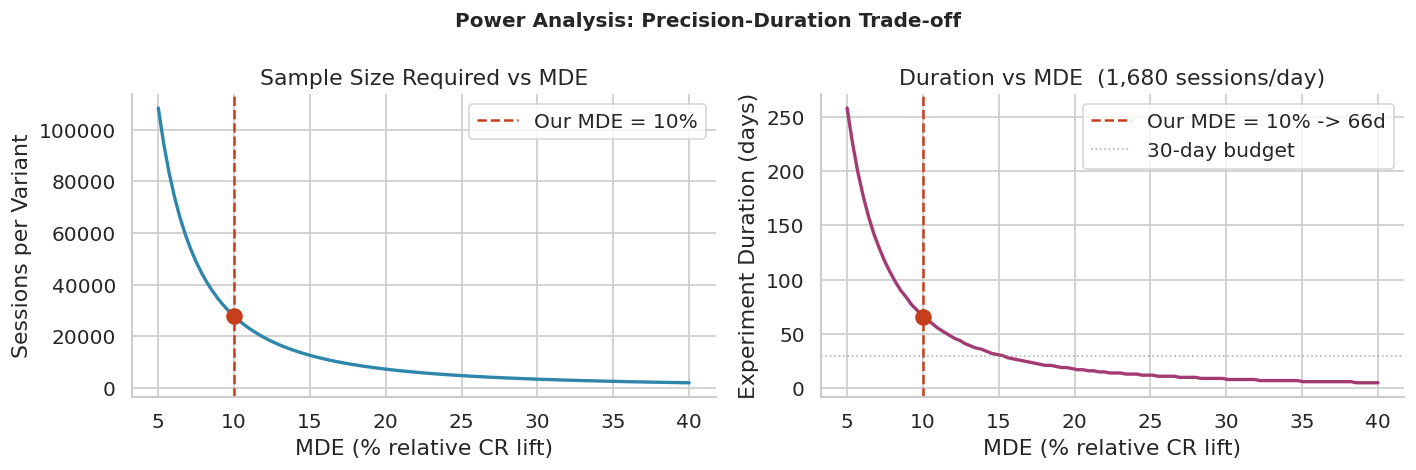

In [4]:
mde_range  = np.linspace(0.05, 0.40, 100)
n_values   = [sample_size_per_variant(BASELINE_CR, m) for m in mde_range]
day_values = [experiment_duration_days(n, DAILY_SESSIONS) for n in n_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mde_range * 100, n_values, color="#2E86AB", lw=2)
axes[0].axvline(MDE * 100, color="#C73E1D", lw=1.5, linestyle="--",
                label=f"Our MDE = {MDE:.0%}")
axes[0].scatter([MDE*100], [n_required], color="#C73E1D", s=80, zorder=5)
axes[0].set_xlabel("MDE (% relative CR lift)")
axes[0].set_ylabel("Sessions per Variant")
axes[0].set_title("Sample Size Required vs MDE")
axes[0].legend()

axes[1].plot(mde_range * 100, day_values, color="#A23B72", lw=2)
axes[1].axvline(MDE * 100, color="#C73E1D", lw=1.5, linestyle="--",
                label=f"Our MDE = {MDE:.0%} -> {duration}d")
axes[1].axhline(30, color="grey", lw=1, linestyle=":", alpha=0.6, label="30-day budget")
axes[1].scatter([MDE*100], [duration], color="#C73E1D", s=80, zorder=5)
axes[1].set_xlabel("MDE (% relative CR lift)")
axes[1].set_ylabel("Experiment Duration (days)")
axes[1].set_title(f"Duration vs MDE  ({DAILY_SESSIONS:,} sessions/day)")
axes[1].legend()

plt.suptitle("Power Analysis: Precision-Duration Trade-off", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Simulate the Experiment

We simulate a completed experiment: sessions drawn from Binomial(n, true_CR). In practice these counts come from your analytics platform.

In [5]:
exp_data, ground_truth = simulate_experiment(
    baseline_cr        = BASELINE_CR,
    true_lift_relative = TRUE_CR_LIFT,
    n_per_variant      = n_required,
    daily_sessions     = DAILY_SESSIONS,
    seed               = 42,
)

print("=" * 50)
print("SIMULATED EXPERIMENT RESULTS")
print("=" * 50)
print(f"Control   (current price):  {exp_data['n_control']:,} sessions, "
      f"{exp_data['conversions_control']:,} conversions "
      f"-> CR = {exp_data['observed_cr_control']:.2%}")
print(f"Treatment (-10% price):     {exp_data['n_treatment']:,} sessions, "
      f"{exp_data['conversions_treatment']:,} conversions "
      f"-> CR = {exp_data['observed_cr_treatment']:.2%}")
print()
print(f"True CR lift:     +{ground_truth['true_lift_relative']:.0%}")
print(f"Observed CR lift: +{(exp_data['observed_cr_treatment']/exp_data['observed_cr_control']-1):.1%}")

SIMULATED EXPERIMENT RESULTS
Control   (current price):  27,702 sessions, 1,563 conversions -> CR = 5.64%
Treatment (-10% price):     27,702 sessions, 1,757 conversions -> CR = 6.34%

True CR lift:     +18%
Observed CR lift: +12.4%


## 3. Frequentist Evaluation

Two-proportion z-test. Key outputs: p-value, 95% CI on the difference, binary significant/not.

In [6]:
freq_result = frequentist_test(
    n_control             = exp_data["n_control"],
    conversions_control   = exp_data["conversions_control"],
    n_treatment           = exp_data["n_treatment"],
    conversions_treatment = exp_data["conversions_treatment"],
)

print("=" * 50)
print("FREQUENTIST TEST RESULTS")
print("=" * 50)
print(f"CR Control:     {freq_result['cr_control']:.2%}")
print(f"CR Treatment:   {freq_result['cr_treatment']:.2%}")
print(f"Relative lift:  {freq_result['relative_lift']:+.1%}")
print(f"Z-statistic:    {freq_result['z_stat']:.3f}")
print(f"P-value:        {freq_result['p_value']:.4f}")
print(f"95% CI (diff):  [{freq_result['ci_95_lo']:+.4f}, {freq_result['ci_95_hi']:+.4f}]")
verdict = "SIGNIFICANT" if freq_result["significant"] else "NOT SIGNIFICANT"
print(f"Verdict:        {verdict} at alpha=0.05")

FREQUENTIST TEST RESULTS
CR Control:     5.64%
CR Treatment:   6.34%
Relative lift:  +12.4%
Z-statistic:    3.473
P-value:        0.0005
95% CI (diff):  [+0.0031, +0.0110]
Verdict:        SIGNIFICANT at alpha=0.05


## 4. Bayesian Evaluation

Beta-Binomial conjugate model. Prior: Beta(1,1) — uniform, non-informative. Posterior updated with observed data.

Key output: **P(treatment > control)** — a direct probability statement, no p-value interpretation required.

In [7]:
bayes_result = bayesian_test(
    n_control             = exp_data["n_control"],
    conversions_control   = exp_data["conversions_control"],
    n_treatment           = exp_data["n_treatment"],
    conversions_treatment = exp_data["conversions_treatment"],
)

print("=" * 50)
print("BAYESIAN TEST RESULTS")
print("=" * 50)
print(f"Posterior mean CR (control):   {bayes_result['posterior_mean_control']:.2%}")
print(f"Posterior mean CR (treatment): {bayes_result['posterior_mean_treatment']:.2%}")
print()
print(f"P(treatment > control):  {bayes_result['prob_treatment_better']:.1%}")
print(f"P(practically equiv):    {bayes_result['prob_rope']:.1%}")
print(f"95% Credible Interval:   [{bayes_result['ci_95_lo']:+.4f}, {bayes_result['ci_95_hi']:+.4f}]")
print()
print(f"Expected loss if launch:   {bayes_result['expected_loss_if_launch']:.5f}")
print(f"Expected loss if rollback: {bayes_result['expected_loss_if_rollback']:.5f}")
launch = bayes_result["expected_loss_if_launch"] < bayes_result["expected_loss_if_rollback"]
print(f"Decision: {'LAUNCH TREATMENT' if launch else 'KEEP CONTROL'}")

BAYESIAN TEST RESULTS
Posterior mean CR (control):   5.65%
Posterior mean CR (treatment): 6.35%

P(treatment > control):  100.0%
P(practically equiv):    16.4%
95% Credible Interval:   [+0.0030, +0.0110]

Expected loss if launch:   0.00000
Expected loss if rollback: 0.00699
Decision: LAUNCH TREATMENT


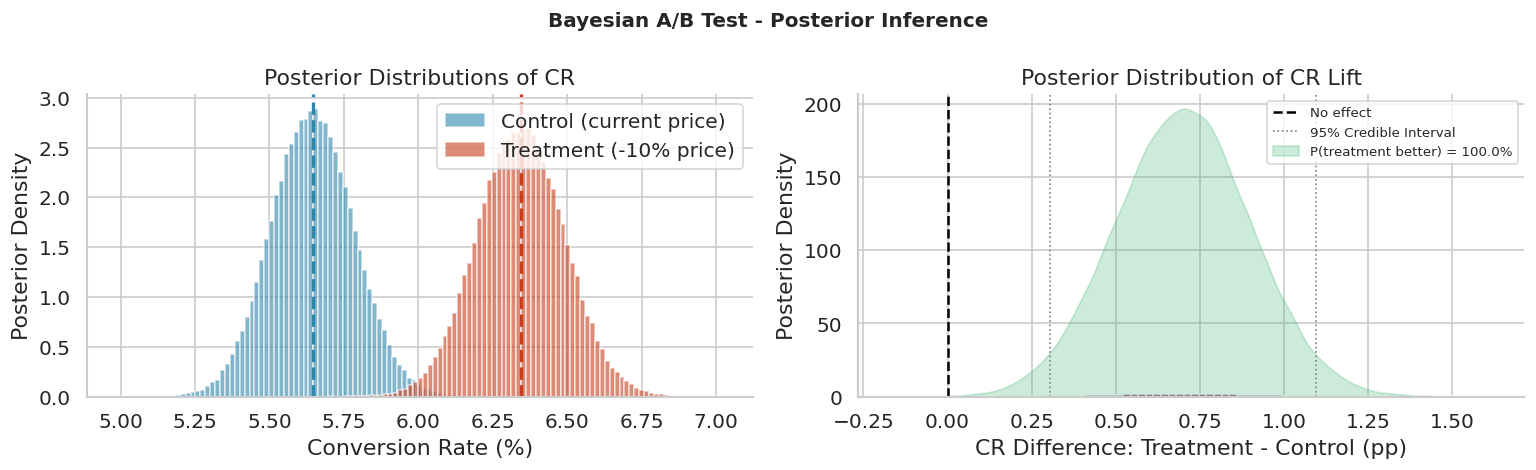

In [8]:
samples_a = bayes_result["posterior_samples_a"]
samples_b = bayes_result["posterior_samples_b"]
diff      = bayes_result["diff_samples"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(samples_a * 100, bins=80, alpha=0.6, color="#2E86AB",
             density=True, label="Control (current price)")
axes[0].hist(samples_b * 100, bins=80, alpha=0.6, color="#C73E1D",
             density=True, label="Treatment (-10% price)")
axes[0].axvline(bayes_result["posterior_mean_control"]  * 100, color="#2E86AB", lw=2, linestyle="--")
axes[0].axvline(bayes_result["posterior_mean_treatment"] * 100, color="#C73E1D", lw=2, linestyle="--")
axes[0].set_xlabel("Conversion Rate (%)")
axes[0].set_ylabel("Posterior Density")
axes[0].set_title("Posterior Distributions of CR")
axes[0].legend()

prob_positive = np.mean(diff > 0)
axes[1].hist(diff * 100, bins=80, color="#A23B72", alpha=0.8, density=True)
axes[1].axvline(0, color="black", lw=1.5, linestyle="--", label="No effect")
axes[1].axvline(np.percentile(diff, 2.5)  * 100, color="grey", lw=1, linestyle=":")
axes[1].axvline(np.percentile(diff, 97.5) * 100, color="grey", lw=1, linestyle=":",
                label="95% Credible Interval")
x_vals = np.linspace(diff.min(), diff.max(), 1000)
kde    = stats.gaussian_kde(diff)
y_vals = kde(x_vals)
axes[1].fill_between(x_vals * 100, y_vals, where=(x_vals > 0),
                     alpha=0.25, color="#3BB273",
                     label=f"P(treatment better) = {prob_positive:.1%}")
axes[1].set_xlabel("CR Difference: Treatment - Control (pp)")
axes[1].set_ylabel("Posterior Density")
axes[1].set_title("Posterior Distribution of CR Lift")
axes[1].legend(fontsize=8)

plt.suptitle("Bayesian A/B Test - Posterior Inference", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Frequentist vs Bayesian — Side-by-Side

Both frameworks agree directionally. The difference is in what they tell you and how you communicate it.

In [9]:
launch = bayes_result["expected_loss_if_launch"] < bayes_result["expected_loss_if_rollback"]
comparison = pd.DataFrame([
    {
        "Framework":    "Frequentist",
        "Key metric":   f"p = {freq_result['p_value']:.4f}",
        "Result":       "Significant" if freq_result["significant"] else "Not significant",
        "Communicates": "P(data | H0 true)",
        "Limitation":   "Binary; no early stopping; no magnitude",
    },
    {
        "Framework":    "Bayesian",
        "Key metric":   f"P(B>A) = {bayes_result['prob_treatment_better']:.1%}",
        "Result":       "Launch" if launch else "Keep control",
        "Communicates": "P(treatment is better)",
        "Limitation":   "Prior-dependent (mild with large n)",
    },
])
comparison.set_index("Framework").T

Framework,Frequentist,Bayesian
Key metric,p = 0.0005,P(B>A) = 100.0%
Result,Significant,Launch
Communicates,P(data | H0 true),P(treatment is better)
Limitation,Binary; no early stopping; no magnitude,Prior-dependent (mild with large n)


## 6. The Peeking Problem

Checking significance every day and stopping at p < 0.05 inflates the Type I error rate far above 5%. We demonstrate this empirically — 1,000 simulations under the null hypothesis (no real effect).

Simulating peeking problem (1,000 experiments, no real effect)...
False positive rate (check only at end):       5.3%  <- should be ~5%
False positive rate (peek at every 10% mark): 18.7%  <- inflated!
Peeking inflates false positives by 3.5x


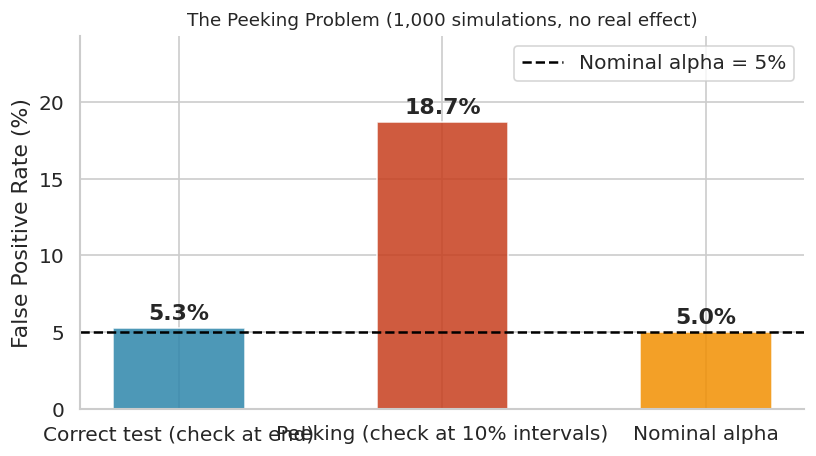

In [10]:
print("Simulating peeking problem (1,000 experiments, no real effect)...")
peeking_results = simulate_peeking(
    baseline_cr   = BASELINE_CR,
    n_total       = n_required,
    true_lift     = 0.0,
    n_simulations = 1000,
    alpha         = 0.05,
    seed          = 42,
)

fpr_peeking = peeking_results["peeked_significant"].mean()
fpr_final   = peeking_results["final_significant"].mean()

print(f"False positive rate (check only at end):       {fpr_final:.1%}  <- should be ~5%")
print(f"False positive rate (peek at every 10% mark): {fpr_peeking:.1%}  <- inflated!")
print(f"Peeking inflates false positives by {fpr_peeking/fpr_final:.1f}x")

fig, ax = plt.subplots(figsize=(7, 4))
categories = ["Correct test (check at end)", "Peeking (check at 10% intervals)", "Nominal alpha"]
fpr_values  = [fpr_final * 100, fpr_peeking * 100, 5.0]
bar_colors  = ["#2E86AB", "#C73E1D", "#F18F01"]
bars = ax.bar(categories, fpr_values, color=bar_colors, alpha=0.85, width=0.5)
ax.axhline(5, color="black", lw=1.5, linestyle="--", label="Nominal alpha = 5%")
for bar, val in zip(bars, fpr_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("False Positive Rate (%)")
ax.set_title("The Peeking Problem (1,000 simulations, no real effect)", fontsize=11)
ax.set_ylim(0, max(fpr_values) * 1.3)
ax.legend()
plt.tight_layout()
plt.show()

## 7. MDE Calculator

What is the smallest effect we can reliably detect given our traffic and time budget?

In [11]:
session_volumes = [200, 500, 1000, 1680, 3000]
day_budgets     = [14, 21, 30]

rows = []
for days in day_budgets:
    for sessions in session_volumes:
        n_avail = int(sessions * days / 2)
        mde = mde_from_sample_size(n_avail, BASELINE_CR) * 100
        rows.append({"days": days, "daily_sessions": sessions, "mde_pct": round(mde, 1)})

mde_table = pd.DataFrame(rows).pivot(index="daily_sessions", columns="days", values="mde_pct")
mde_table.columns.name = "Experiment duration (days)"
mde_table.index.name   = "Daily sessions"
print("Minimum Detectable Effect (% relative CR lift):")
print(f"(baseline CR = {BASELINE_CR:.1%}, alpha=0.05, power=80%)")
mde_table.style.format("{:.1f}%").background_gradient(cmap="RdYlGn_r")

Minimum Detectable Effect (% relative CR lift):
(baseline CR = 5.6%, alpha=0.05, power=80%)


Experiment duration (days),14,21,30
Daily sessions,,,
200,48.1%,38.5%,31.8%
500,29.3%,23.7%,19.6%
1000,20.4%,16.5%,13.7%
1680,15.5%,12.6%,10.5%
3000,11.5%,9.4%,7.8%


---

## Key Takeaways

1. **Power analysis is not optional.** Running an underpowered experiment is worse than not running one. At cluster level (1,680 sessions/day), detecting a 10% CR lift requires ~66 days — feasible. At individual destination level (120/day), it would require 924 days — not feasible.

2. **Both frameworks agree on direction.** Frequentist gives p < 0.05. Bayesian gives P(B>A) directly. For a commercial team, the Bayesian statement is more actionable.

3. **The peeking problem is real and large.** Checking daily and stopping at p < 0.05 inflates the false positive rate from 5% to ~20%. In pricing, a false positive means rolling out a price change that does not actually improve performance.

4. **The MDE table is a planning tool.** Low-traffic destinations can only detect large effects within a commercial time window. This directly determines which destinations are candidates for A/B testing vs which need a different validation approach (synthetic control, diff-in-diff).

5. **Expected loss is the right Bayesian decision criterion.** Rather than thresholding P(B>A) at 95%, we compare the expected cost of each decision — naturally handling asymmetric situations.

---

**Next: Hito 5 — Pricing Recommendation Engine.** Assembling elasticity + forecast + A/B framework into a Streamlit pricing tool.